This notebook was made for plotting nBodySimulation results.

In [20]:
import subprocess
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import re

import benchmarking_nBody

Choose which methods to include. The currently supported options are vulkan_cells, vulkan_naive, cpp_naive

Also choose whether or not to force rerun the benchmarks. Alternatively, old runs will be used (if available)

In [21]:
incl = ["vulkan_naive", "vulkan_cells", "vulkan_verlet", "slang->vulkan_naive", "slang->vulkan_cells", "slang->vulkan_verlet", "slang->ptx_naive", "slang->ptx_cells", "slang->ptx_verlet", "cpp_naive"]
force_rerun         = False
search_hyper_params = True
draw_mean           = True

executables = {
    "vulkan_naive"         : "../build/src/nBodySimulation/vulkan/naive/nbody_vulkan_naive",
    "vulkan_cells"         : "../build/src/nBodySimulation/vulkan/cell_lists/nbody_vulkan_cells",
    "vulkan_verlet"        : "../build/src/nBodySimulation/vulkan/verlet_lists/nbody_vulkan_verlet",
    "slang->vulkan_naive"  : "../build/src/nBodySimulation/slang/naive/nbody_slang_vulkan_naive", 
    "slang->vulkan_cells"  : "../build/src/nBodySimulation/slang/cell_lists/nbody_slang_vulkan_cells", 
    "slang->vulkan_verlet" : "../build/src/nBodySimulation/slang/verlet_lists/nbody_slang_vulkan_verlet", 
    "slang->ptx_naive"     : "../build/src/nBodySimulation/slang/naive/nbody_slang_cuda_naive", 
    "slang->ptx_cells"     : "../build/src/nBodySimulation/slang/cell_lists/nbody_slang_cuda_cells", 
    "slang->ptx_verlet"    : "../build/src/nBodySimulation/slang/verlet_lists/nbody_slang_cuda_verlet", 
    "cpp_naive"            : "../build/src/nBodySimulation/cpp/nbody_cpp"
}

tests = {
    "vulkan_naive"         : "../build/test/nBodySimulation/vulkan/naive/nbody_vulkan_naive_test",
    "vulkan_cells"         : "../build/test/nBodySimulation/vulkan/cell_lists/nbody_vulkan_cells_test",
    "vulkan_verlet"        : "../build/test/nBodySimulation/vulkan/verlet_lists/nbody_vulkan_verlet_test",
    "slang->vulkan_naive"  : "../build/test/nBodySimulation/slang/vulkan/naive/nbody_slang_vulkan_naive_test", 
    "slang->vulkan_cells"  : "../build/test/nBodySimulation/slang/vulkan/cell_lists/nbody_slang_vulkan_cells_test", 
    "slang->vulkan_verlet" : "../build/test/nBodySimulation/slang/vulkan/verlet_lists/nbody_slang_vulkan_verlet_test", 
    "slang->ptx_naive"     : "../build/test/nBodySimulation/slang/cuda/naive/nbody_slang_cuda_naive_test", 
    "slang->ptx_cells"     : "../build/test/nBodySimulation/slang/cuda/cell_lists/nbody_slang_cuda_cells_test", 
    "slang->ptx_verlet"    : "../build/test/nBodySimulation/slang/cuda/verlet_lists/nbody_slang_cuda_verlet_test", 
    "cpp_naive"            : "../build/test/nBodySimulation/cpp/nbody_cpp_test"

}

results = {
    "vulkan_naive"         : "../results/nBody_vulkan_naive.json",
    "vulkan_cells"         : "../results/nBody_vulkan_cells.json",
    "vulkan_verlet"        : "../results/nBody_vulkan_verlet.json",
    "slang->vulkan_naive"  : "../results/nBody_slang_vulkan_naive.json", 
    "slang->vulkan_cells"  : "../results/nBody_slang_vulkan_cells.json", 
    "slang->vulkan_verlet" : "../results/nBody_slang_vulkan_verlet.json", 
    "slang->ptx_naive"     : "../results/nBody_slang_cuda_naive.json", 
    "slang->ptx_cells"     : "../results/nBody_slang_cuda_cells.json", 
    "slang->ptx_verlet"    : "../results/nBody_slang_cuda_verlet.json", 
    "cpp_naive"            : "../results/nBody_cpp_naive.json"
}
        

In [22]:
def run_benchmark(method):
    print("Now running " + method + " benchmark...")
    executable_path = executables[method]
    result_path = results[method]
    command = [executable_path, f"--benchmark_out={result_path}", "--benchmark_out_format=json"]
    result = subprocess.run(command, capture_output=True, text=True, check=True)
    print(result.stdout, "\n")

def file_exists(filepath):
    return os.path.exists(filepath)

def validate_json_file(method):
    try:
        with open(results[method]) as f:
            json.load(f)
        return True
    except:
        return False
        

In [23]:
benchmarking_nBody.run_cmake()
if force_rerun:
    for method in incl:
        if not file_exists(executables[method]):
            raise FileNotFoundError(f"The executable for {method} was not found in the build directory. Reconfigure the project to build the correct files!")
    for method in incl:
        run_benchmark(method=method)
else:
    for method in incl:
        if not file_exists(results[method]):
            print(f"Could not find results for {method}...")
            if not file_exists(executables[method]):
                raise FileNotFoundError(f"The executable for {method} was not found in the build directory. Reconfigure the project to build the correct files!")
            run_benchmark(method)
        if not validate_json_file(method):
            print(f"Could not validate json results file for {method}.")
            run_benchmark(method)

for method in incl:
    if not validate_json_file(method):
        raise FileNotFoundError(f"The result file for {method} was not found or could not be opened.")
        

[1/174] Slang -> GLSL (.comp): KernelResetCells
[2/172] Slang -> GLSL (.comp): KernelPosition
[3/170] Slang -> GLSL (.comp): KernelIdCells
[4/168] Slang -> GLSL (.comp): KernelPosition
[5/166] Slang -> GLSL (.comp): KernelBlockSum
[6/164] Slang -> GLSL (.comp): KernelBlockSum
[7/162] Slang -> GLSL (.comp): KernelPosition
[8/160] Slang -> GLSL (.comp): KernelForce
[9/158] Slang -> GLSL (.comp): KernelVelocity
[10/156] Slang -> GLSL (.comp): KernelHistogram
[11/154] Slang -> GLSL (.comp): KernelCountNeighbors
[12/152] Compile vulkan compute shader from file '/home/moritzbeste/Documents/projects/uni/bachelorarbeit/performance-portability-benchmark/src/nBodySimulation/vulkan/naive/KernelForce.comp' to '/home/moritzbeste/Documents/projects/uni/bachelorarbeit/performance-portability-benchmark/build/src/nBodySimulation/vulkan/naive/KernelForce.comp.spv'.
/home/moritzbeste/Documents/projects/uni/bachelorarbeit/performance-portability-benchmark/src/nBodySimulation/vulkan/naive/KernelForce.comp


Now all results should exist. Next the files need to be read.


In [24]:
def add_problem_size_column(df):
    df = df.copy()

    df = df[~df["name"].str.contains(r"_(?:mean|median|stddev)$", regex=True)]
    extracted = df["name"].str.extract(r"/(\d+)(?:/|$)")[0]

    if extracted.isna().any():
        bad = df.loc[extracted.isna(), "name"].unique()
        raise ValueError(f"Could not extract problem size N from:\n{bad}")

    df["N"] = extracted.astype(int)
    return df


def add_problem_size_column_mean_only(df):
    df = df.copy()

    df = df[df["name"].str.contains(r"mean$", regex=True)]
    extracted = df["name"].str.extract(r"/(\d+)(?:/|_)")[0]

    if extracted.isna().any():
        bad = df.loc[extracted.isna(), "name"].unique()
        raise ValueError(f"Could not extract N from:\n{bad}")

    df["N"] = extracted.astype(int)
    return df


In [25]:
def get_dataframes():    
    dataframes = {}
    for method in incl:
        with open(results[method], 'r') as f:
            data = json.load(f)
        benchmarks = data["benchmarks"]
        
        df = pd.DataFrame(benchmarks)
        if draw_mean:
            df = df[df["name"].str.endswith("_mean")]
        else:
            df = df[df["run_type"] == "iteration"]
        df = df.drop(columns=["family_index", "per_family_instance_index", "run_name", 
            "run_type", "repetitions", "repetition_index", 
            "threads", "iterations", "cpu_coefficient", 
            "real_coefficient", "big_o", "rms", 
            "aggregate_name", "aggregate_unit"])
        df["real_time_s"] = df["real_time"] / 1e9
        df["cpu_time_s"]  = df["cpu_time"]  / 1e9

        if draw_mean:
            dataframes[method] = add_problem_size_column_mean_only(df)
        else:
            dataframes[method] = add_problem_size_column(df)
    return dataframes

Now we display the results in matplotlib graphs.

In [26]:
def plot_single(df, title, git_hash=None):
    plt.figure(figsize=(8,5))
    plt.plot(df["N"], df["real_time_s"], marker="o")
    plt.xscale("log")
    plt.xlabel("N (problem size)")
    plt.ylabel("Real time (s)")
    plt.title(title)
    plt.grid(True)

    if git_hash:
        plt.figtext(
            0.5, -0.05,
            f"git hash: {git_hash}",
            ha="center", fontsize=8, color="gray"
        )

    plt.show()

def plot_overlay(dataframes, git_hash=None):
    plt.figure(figsize=(8,5))

    for label, df in dataframes.items():
        df = add_problem_size_column_mean_only(df)
        plt.plot(df["N"], df["real_time_s"], marker="o", label=label)

    plt.xscale("log")
    plt.xlabel("N (problem size)")
    plt.ylabel("Real time (s)")
    plt.title("Benchmark Comparison")
    plt.grid(True)
    plt.legend()

    if git_hash:
        plt.figtext(
            0.5, -0.05,
            f"git hash: {git_hash}",
            ha="center", fontsize=8, color="gray"
        )

    plt.show()

searching hyper parameters...
Searching hyper parameter TILE_SIZE...
[1/174] Slang -> GLSL (.comp): KernelBlockSum
[2/174] Slang -> GLSL (.comp): KernelIdCells
[3/174] Slang -> GLSL (.comp): KernelVelocity
[4/174] Slang -> GLSL (.comp): KernelPosition
[5/174] Slang -> GLSL (.comp): KernelForce
[6/174] Slang -> GLSL (.comp): KernelHistogram
[7/174] Slang -> GLSL (.comp): KernelPosition
[8/174] Slang -> GLSL (.comp): KernelBlockSum
[9/174] Slang -> GLSL (.comp): KernelPosition
[10/174] Slang -> GLSL (.comp): KernelVelocity
[11/174] Slang -> GLSL (.comp): KernelVelocity
[12/174] Slang -> GLSL (.comp): KernelCountNeighbors
[13/174] Slang -> GLSL (.comp): KernelResetCells
[14/174] Compile vulkan compute shader from file '/home/moritzbeste/Documents/projects/uni/bachelorarbeit/performance-portability-benchmark/src/nBodySimulation/vulkan/naive/KernelVelocity.comp' to '/home/moritzbeste/Documents/projects/uni/bachelorarbeit/performance-portability-benchmark/build/src/nBodySimulation/vulkan/nai

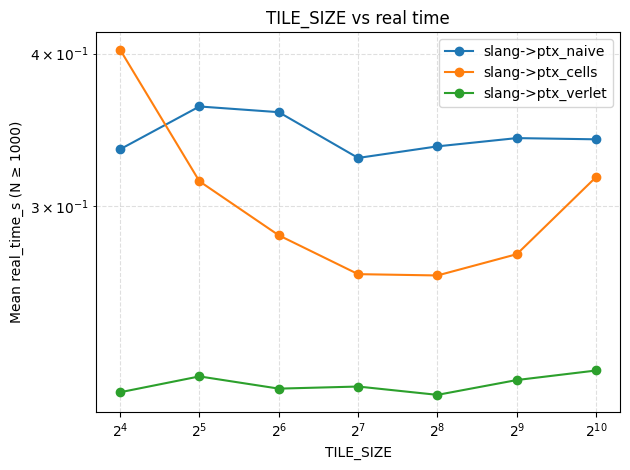

Searching hyper parameter h...
[1/66] Building CXX object src/nBodySimulation/cpp/CMakeFiles/nbody_cpp_lib.dir/Impl_Cpp.cpp.o
In file included from /home/moritzbeste/Documents/projects/uni/bachelorarbeit/performance-portability-benchmark/src/nBodySimulation/Particle.h:9,
                 from /home/moritzbeste/Documents/projects/uni/bachelorarbeit/performance-portability-benchmark/src/nBodySimulation/NBodySimulation.h:21,
                 from /home/moritzbeste/Documents/projects/uni/bachelorarbeit/performance-portability-benchmark/src/nBodySimulation/cpp/Impl_Cpp.h:10,
                 from /home/moritzbeste/Documents/projects/uni/bachelorarbeit/performance-portability-benchmark/src/nBodySimulation/cpp/Impl_Cpp.cpp:1:
/home/moritzbeste/Documents/projects/uni/bachelorarbeit/performance-portability-benchmark/src/common/UtilityFloatArithmetic.h:73:90: warning: ‘host’ attribute directive ignored [-Wattributes]
   73 |     __attribute__((host)) __attribute__((device)) inline T ceilDiv(cons

KeyboardInterrupt: 

In [ ]:
git_hash = subprocess.check_output(["git", "rev-parse", "HEAD"], text=True).strip()
if search_hyper_params:
    print("searching hyper parameters...")

    print("Searching hyper parameter TILE_SIZE...")
    incl_search_TILE_SIZE = ["vulkan_verlet", "slang->vulkan_verlet", "vulkan_cells", "slang->vulkan_cells", "slang->ptx_cells", "slang->ptx_verlet"]
    search_range_TILE_SIZE = [2**i for i in range(4, 11)]
    dataframes_TILE_SIZE = benchmarking_nBody.search_TILE_SIZE(executables, incl_search_TILE_SIZE, search_range_TILE_SIZE)
    benchmarking_nBody.plot_summary(dataframes_TILE_SIZE, groupby="TILE_SIZE", xlabel="TILE_SIZE", title="TILE_SIZE vs real time")

    print("Searching hyper parameter h...")
    incl_search_h = ["vulkan_cells", "slang->vulkan_cells", "slang->ptx_cells"]
    search_range_h = [9.0 * i for i in range(1, 17)]
    dataframes_h = benchmarking_nBody.search_h(executables, incl_search_h, search_range_h)
    benchmarking_nBody.plot_summary(dataframes_h, groupby="h", xlabel="h", title="h vs real time")

    print("Searching hyper parameter influenceRadius...")
    incl_search_inflRad = ["vulkan_verlet", "slang->vulkan_verlet", "slang->ptx_verlet"]
    search_range_inflRad = [4.0 * i for i in range(1, 17)]
    dataframes_inflRad = benchmarking_nBody.search_influenceRadius(executables, incl_search_inflRad, search_range_inflRad)
    benchmarking_nBody.plot_summary(dataframes_inflRad, groupby="Influence Radius", xlabel="Influence Radius", title="Influence Radius vs real time")

    print("Searching hyper parameter interval_neighbor_search...")
    incl_search_interval = ["vulkan_verlet", "slang->vulkan_verlet", "vulkan_cells", "slang->vulkan_cells"]
    search_range_interval = [5 * i for i in range(1, 10)]
    highest_pass = benchmarking_nBody.search_interval_neighbor_search(executables=tests, incl=incl_search_interval, search_range=search_range_interval)
    print("Highest passing interval_neighbor_search:", highest_pass)

    # reset constants
    old_tile_size = int(benchmarking_nBody.find_const_in_file("TILE_SIZE"))
    new_tile_size = 256
    benchmarking_nBody.update_tile_size(old_tile_size=old_tile_size, new_tile_size=new_tile_size)

    old_h = float(benchmarking_nBody.find_const_in_file(search_string="FloatType h"))
    h = 9.0
    new_conf_line_h = f"FloatType h{{{h}}};"
    old_conf_line_h = f"FloatType h{{{old_h}}};"
    benchmarking_nBody.repl(old=old_conf_line_h, new=new_conf_line_h)

    old_inflRad = float(benchmarking_nBody.find_const_in_file(search_string="FloatType influenceRadius"))
    inflRad = 4.0
    new_conf_line_inflRad = f"FloatType influenceRadius{{{inflRad}}};"
    old_conf_line_inflRad = f"FloatType influenceRadius{{{old_inflRad}}};"
    benchmarking_nBody.repl(old=old_conf_line_inflRad, new=new_conf_line_inflRad)

    old_interval = int(benchmarking_nBody.find_const_in_file(search_string="static constexpr uint interval_neighbor_search"))
    interval = 10
    new_conf_line_interval = f"static constexpr uint interval_neighbor_search{{{interval}}};"
    old_conf_line_interval = f"static constexpr uint interval_neighbor_search{{{old_interval}}};"
    benchmarking_nBody.repl(old=old_conf_line_interval, new=new_conf_line_interval)

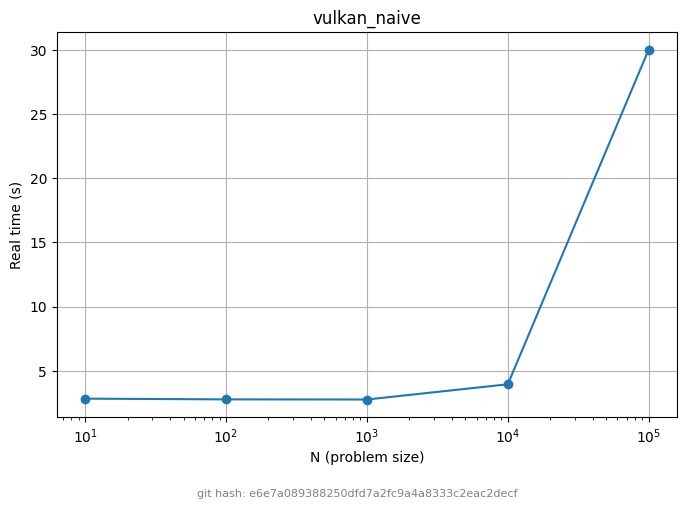

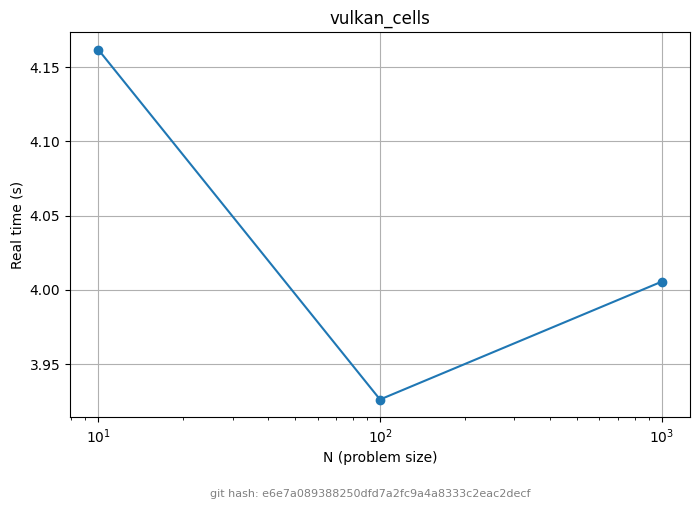

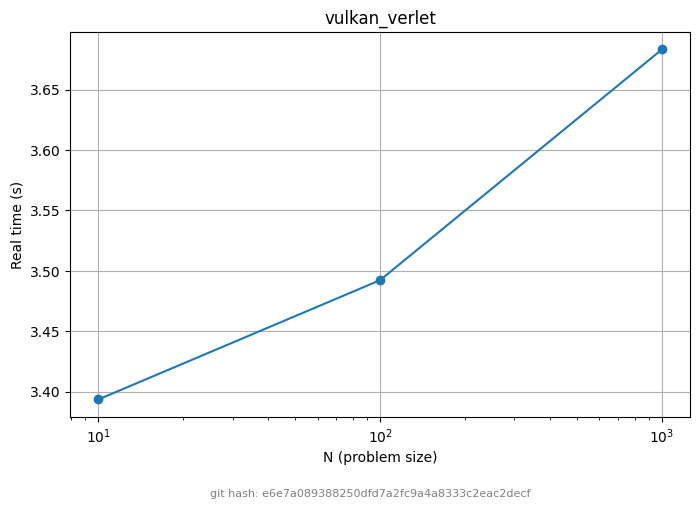

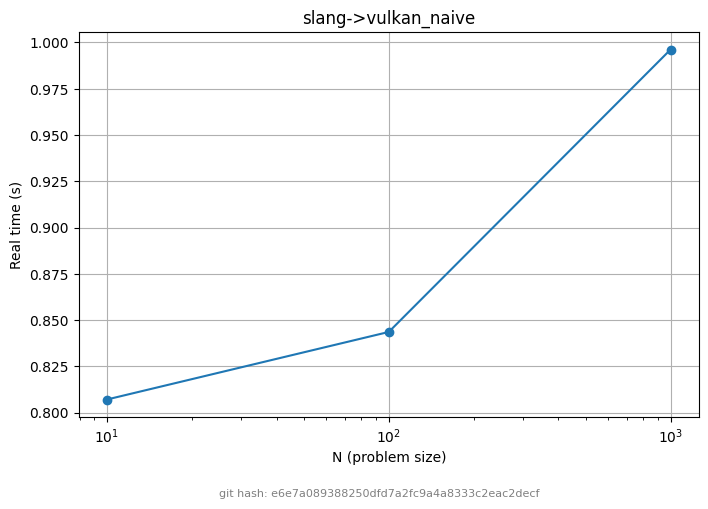

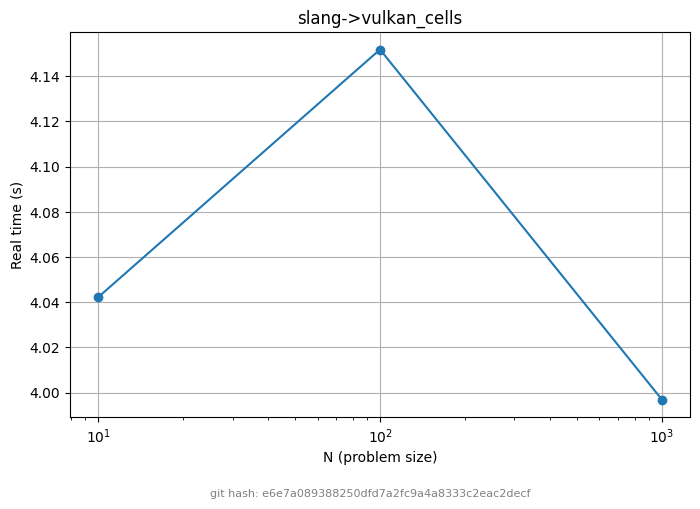

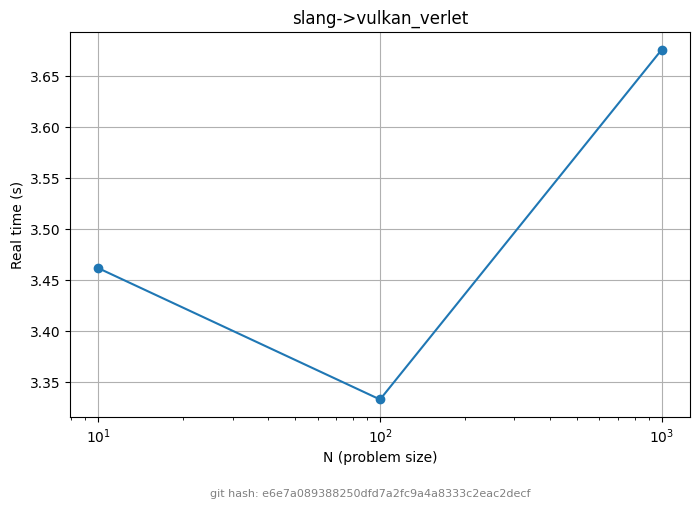

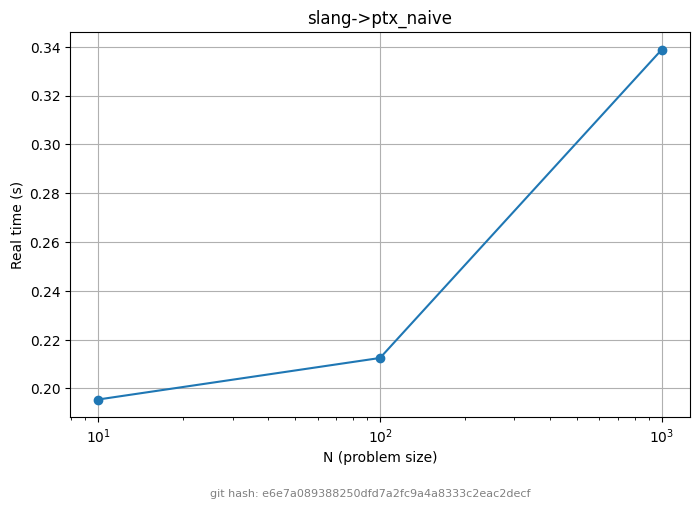

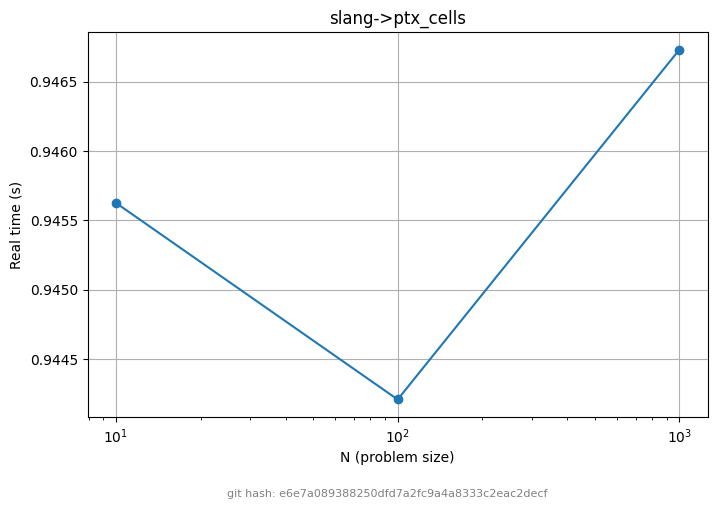

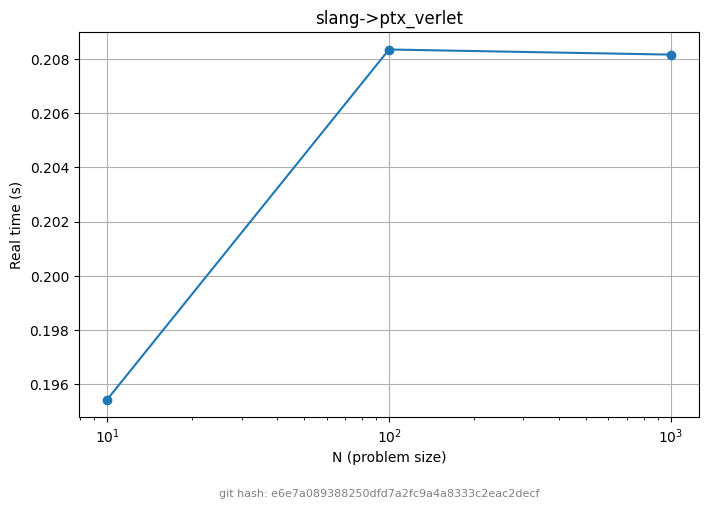

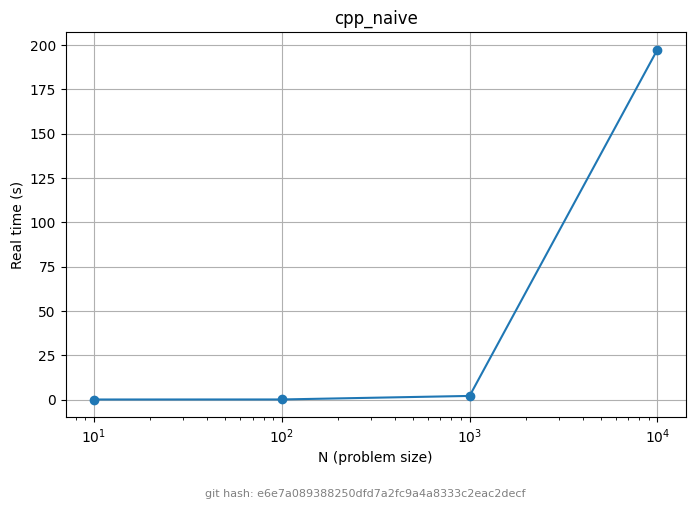

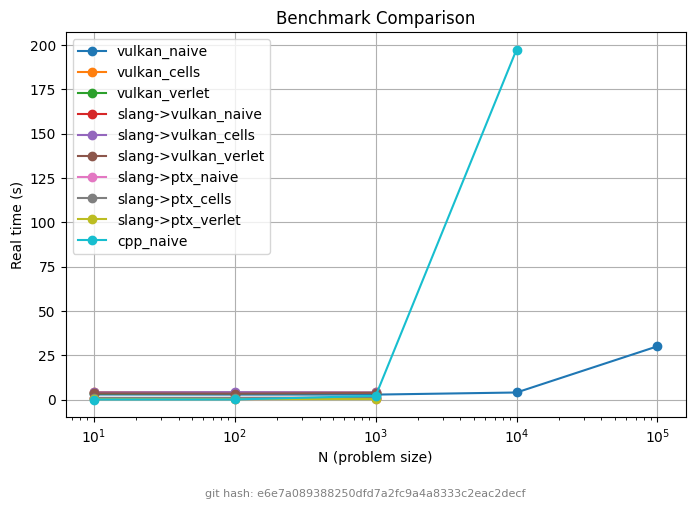

In [ ]:
dataframes = get_dataframes()
for method in incl:
    plot_single(dataframes[method], method, git_hash)
plot_overlay(dataframes, git_hash)